In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# Install if needed
# pip install nltk scikit-learn

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("All imports successful")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\varun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\varun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\varun\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\varun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


All imports successful


In [2]:
sample_text = """
Natural Language Processing (NLP) is a field of AI that gives machines 
the ability to read, understand, and derive meaning from human language. 
It's used in chatbots, translation, sentiment analysis, and much more!
"""

# Step 1 — Lowercase
text = sample_text.lower()
print("Lowercase:\n", text)

# Step 2 — Remove punctuation and special characters
text = re.sub(r'[^a-zA-Z\s]', '', text)
print("Cleaned:\n", text)

# Step 3 — Tokenization — split into individual words
tokens = word_tokenize(text)
print("Tokens:", tokens)
print("Token count:", len(tokens))

# Step 4 — Remove stopwords
# Stopwords = common words that carry no meaning (the, is, and, in...)
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print("\nAfter removing stopwords:", filtered_tokens)
print("Token count after:", len(filtered_tokens))

# Step 5 — Stemming vs Lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ['running', 'runs', 'ran', 'easily', 'fairly', 'studies', 'studying']

print("\nStemming vs Lemmatization:")
print(f"{'Word':<12} {'Stemmed':<12} {'Lemmatized'}")
print("-" * 36)
for word in words:
    print(f"{word:<12} {stemmer.stem(word):<12} {lemmatizer.lemmatize(word)}")

Lowercase:
 
natural language processing (nlp) is a field of ai that gives machines 
the ability to read, understand, and derive meaning from human language. 
it's used in chatbots, translation, sentiment analysis, and much more!

Cleaned:
 
natural language processing nlp is a field of ai that gives machines 
the ability to read understand and derive meaning from human language 
its used in chatbots translation sentiment analysis and much more

Tokens: ['natural', 'language', 'processing', 'nlp', 'is', 'a', 'field', 'of', 'ai', 'that', 'gives', 'machines', 'the', 'ability', 'to', 'read', 'understand', 'and', 'derive', 'meaning', 'from', 'human', 'language', 'its', 'used', 'in', 'chatbots', 'translation', 'sentiment', 'analysis', 'and', 'much', 'more']
Token count: 33

After removing stopwords: ['natural', 'language', 'processing', 'nlp', 'field', 'ai', 'gives', 'machines', 'ability', 'read', 'understand', 'derive', 'meaning', 'human', 'language', 'used', 'chatbots', 'translation', 'se

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

# Simple corpus — collection of documents
corpus = [
    "I love machine learning",
    "I love deep learning",
    "deep learning is amazing",
    "machine learning is powerful"
]

# CountVectorizer does all preprocessing + counting
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

# Show as DataFrame for clarity
bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)
print("Bag of Words Matrix:")
print(bow_df)
print("\nVocabulary size:", len(vectorizer.vocabulary_))

Bag of Words Matrix:
   amazing  deep  is  learning  love  machine  powerful
0        0     0   0         1     1        1         0
1        0     1   0         1     1        0         0
2        1     1   1         1     0        0         0
3        0     0   1         1     0        1         1

Vocabulary size: 7


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf.get_feature_names_out()
)
print("TF-IDF Matrix:")
print(tfidf_df)


TF-IDF Matrix:
   amazing   deep     is  learning  love  machine  powerful
0    0.000  0.000  0.000     0.424  0.64    0.640     0.000
1    0.000  0.640  0.000     0.424  0.64    0.000     0.000
2    0.631  0.497  0.497     0.329  0.00    0.000     0.000
3    0.000  0.000  0.497     0.329  0.00    0.497     0.631


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf.get_feature_names_out()
)
print("TF-IDF Matrix:")
print(tfidf_df)


TF-IDF Matrix:
   amazing   deep     is  learning  love  machine  powerful
0    0.000  0.000  0.000     0.424  0.64    0.640     0.000
1    0.000  0.640  0.000     0.424  0.64    0.000     0.000
2    0.631  0.497  0.497     0.329  0.00    0.000     0.000
3    0.000  0.000  0.497     0.329  0.00    0.497     0.631


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_files
import urllib.request
import os

reviews = [
    ("This movie was absolutely fantastic and wonderful", "positive"),
    ("I loved every minute of this brilliant film", "positive"),
    ("Amazing performances and incredible storyline", "positive"),
    ("The best movie I have seen in years", "positive"),
    ("Outstanding direction and beautiful cinematography", "positive"),
    ("A masterpiece of modern cinema truly exceptional", "positive"),
    ("Heartwarming story with great characters", "positive"),
    ("Superb acting and gripping plot from start to finish", "positive"),
    ("This film was terrible and boring throughout", "negative"),
    ("Worst movie I have ever seen complete waste of time", "negative"),
    ("Awful script with poor acting and bad direction", "negative"),
    ("I hated this film it was painfully dull", "negative"),
    ("Disappointing and dreadful in every possible way", "negative"),
    ("The plot made no sense and acting was horrible", "negative"),
    ("Boring and predictable with no redeeming qualities", "negative"),
    ("A complete disaster of a film avoid at all costs", "negative"),
]

# Prepare data
texts  = [r[0] for r in reviews]
labels = [1 if r[1] == "positive" else 0 for r in reviews]

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(texts)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

# Train classifier
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.25

Classification Report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.00      0.00      0.00         3

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4



C:\Users\varun\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\varun\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\varun\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [7]:
def predict_sentiment(text, model, vectorizer):
    # Preprocess
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Vectorize
    X = vectorizer.transform([text])
    
    # Predict
    prediction = model.predict(X)[0]
    probability = model.predict_proba(X)[0]
    
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    confidence = max(probability)
    
    print(f"Text: {text}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print()

# Test with new sentences
predict_sentiment("This movie was great and I enjoyed it", clf, tfidf)
predict_sentiment("I did not like this film at all", clf, tfidf)
predict_sentiment("The acting was decent but the plot was confusing", clf, tfidf)

Text: this movie was great and i enjoyed it
Sentiment: Negative 😞
Confidence: 60.27%

Text: i did not like this film at all
Sentiment: Negative 😞
Confidence: 65.76%

Text: the acting was decent but the plot was confusing
Sentiment: Negative 😞
Confidence: 61.06%



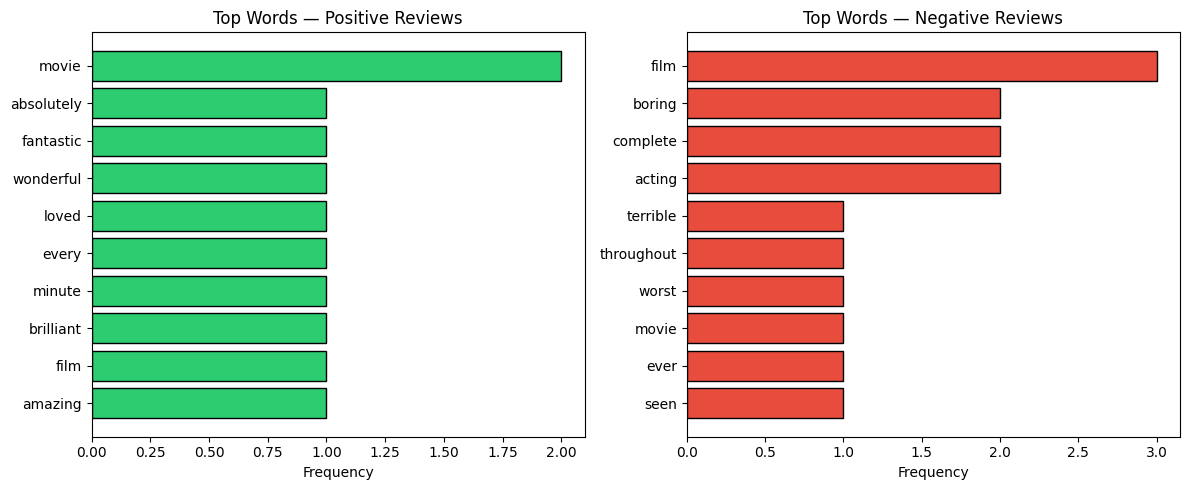

In [8]:
# Visualize most common words in positive vs negative reviews
positive_reviews = " ".join([r[0] for r in reviews if r[1] == "positive"])
negative_reviews = " ".join([r[0] for r in reviews if r[1] == "negative"])

def get_top_words(text, n=10):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    return Counter(tokens).most_common(n)

pos_words = get_top_words(positive_reviews)
neg_words = get_top_words(negative_reviews)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Positive words
axes[0].barh([w[0] for w in pos_words],
              [w[1] for w in pos_words],
              color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words — Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative words
axes[1].barh([w[0] for w in neg_words],
              [w[1] for w in neg_words],
              color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words — Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
